# Lección 5 – Evaluación de Resultados e Informe Final

En esta lección vamos a comparar las distintas segmentaciones obtenidas (K-Means, DBSCAN y agrupamiento jerárquico), evaluar su consistencia y preparar material para el informe final.


## 1. Preparación: volver a calcular las segmentaciones

Cargamos los datos, aplicamos el mismo preprocesamiento que en la Lección 3 y repetimos, de forma resumida, la clusterización de la Lección 4 para disponer de las etiquetas de clúster en este notebook.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score

# Cargar datos
train = pd.read_csv('Train.csv')

# Definir columnas numéricas y categóricas
numeric_features = []
categorical_features = []

for col, dtype in train.dtypes.items():
    if dtype in ['int64', 'float64']:
        numeric_features.append(col)
    else:
        categorical_features.append(col)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

X_train_prep = preprocessor.fit_transform(train)
X_for_clust = X_train_prep.toarray() if hasattr(X_train_prep, 'toarray') else X_train_prep

# Reducción PCA a 2D para visualización
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_for_clust)
X_for_clust.shape, X_pca_2.shape

((8068, 33), (8068, 2))

## 2. K-Means: segmentación y métricas

Aplicamos K-Means con un número de clústeres elegido (por ejemplo, el que resultó razonable en la Lección 4) y calculamos el coeficiente de silueta.


In [2]:
best_k = 4  # ajustar según resultados de la Lección 4

kmeans = KMeans(n_clusters=best_k, random_state=42)
labels_kmeans = kmeans.fit_predict(X_for_clust)

silhouette_kmeans = silhouette_score(X_for_clust, labels_kmeans)
unique_kmeans, counts_kmeans = np.unique(labels_kmeans, return_counts=True)

silhouette_kmeans, dict(zip(unique_kmeans, counts_kmeans))

(0.1251120495805612,
 {np.int32(0): np.int64(1533),
  np.int32(1): np.int64(2310),
  np.int32(2): np.int64(2217),
  np.int32(3): np.int64(2008)})

## 3. DBSCAN: segmentación y métricas

Aplicamos DBSCAN con parámetros elegidos (eps, min_samples) y calculamos el coeficiente de silueta cuando haya al menos dos clústeres válidos.


In [3]:
eps = 0.5
min_samples = 5

dbscan = DBSCAN(eps=eps, min_samples=min_samples)
labels_dbscan = dbscan.fit_predict(X_for_clust)

unique_db, counts_db = np.unique(labels_dbscan, return_counts=True)

# Silueta solo si hay al menos 2 clústeres (excluyendo -1)
labels_unique = set(labels_dbscan)
labels_unique.discard(-1)
if len(labels_unique) > 1:
    mask = labels_dbscan != -1
    silhouette_dbscan = silhouette_score(X_for_clust[mask], labels_dbscan[mask])
else:
    silhouette_dbscan = None

silhouette_dbscan, dict(zip(unique_db, counts_db))

(0.41883037404380236,
 {np.int64(-1): np.int64(7282),
  np.int64(0): np.int64(5),
  np.int64(1): np.int64(13),
  np.int64(2): np.int64(31),
  np.int64(3): np.int64(37),
  np.int64(4): np.int64(79),
  np.int64(5): np.int64(21),
  np.int64(6): np.int64(22),
  np.int64(7): np.int64(8),
  np.int64(8): np.int64(9),
  np.int64(9): np.int64(8),
  np.int64(10): np.int64(7),
  np.int64(11): np.int64(5),
  np.int64(12): np.int64(5),
  np.int64(13): np.int64(7),
  np.int64(14): np.int64(20),
  np.int64(15): np.int64(8),
  np.int64(16): np.int64(7),
  np.int64(17): np.int64(7),
  np.int64(18): np.int64(34),
  np.int64(19): np.int64(7),
  np.int64(20): np.int64(10),
  np.int64(21): np.int64(6),
  np.int64(22): np.int64(13),
  np.int64(23): np.int64(9),
  np.int64(24): np.int64(37),
  np.int64(25): np.int64(12),
  np.int64(26): np.int64(11),
  np.int64(27): np.int64(8),
  np.int64(28): np.int64(8),
  np.int64(29): np.int64(8),
  np.int64(30): np.int64(8),
  np.int64(31): np.int64(6),
  np.int64(32):

## 4. Agrupamiento jerárquico: segmentación y métricas

Aplicamos agrupamiento jerárquico (AgglomerativeClustering) con un número fijo de clústeres y calculamos su silueta.


In [4]:
n_clusters_hier = 4

agg = AgglomerativeClustering(n_clusters=n_clusters_hier)
labels_agg = agg.fit_predict(X_for_clust)

silhouette_agg = silhouette_score(X_for_clust, labels_agg)
unique_agg, counts_agg = np.unique(labels_agg, return_counts=True)

silhouette_agg, dict(zip(unique_agg, counts_agg))

(0.10271159603200981,
 {np.int64(0): np.int64(3631),
  np.int64(1): np.int64(1720),
  np.int64(2): np.int64(1773),
  np.int64(3): np.int64(944)})

## 5. Tabla resumen de métricas de clusterización

Construimos una tabla que compare, para cada algoritmo, el número de clústeres obtenidos, el coeficiente de silueta y la presencia de ruido.


In [5]:
# Número de clústeres efectivos
n_clusters_kmeans = len(np.unique(labels_kmeans))

labels_db_unique = np.unique(labels_dbscan)
n_clusters_dbscan = len(labels_db_unique[labels_db_unique != -1])  # sin contar ruido
n_noise_dbscan = np.sum(labels_dbscan == -1)

n_clusters_agg = len(np.unique(labels_agg))

summary = pd.DataFrame({
    'Algoritmo': ['K-Means', 'DBSCAN', 'Jerárquico'],
    'N_clústeres_efectivos': [n_clusters_kmeans, n_clusters_dbscan, n_clusters_agg],
    'Silueta': [silhouette_kmeans, silhouette_dbscan, silhouette_agg],
    'N_ruido': [0, n_noise_dbscan, 0]
})

summary

,Algoritmo,N_clústeres_efectivos,Silueta,N_ruido
0,K-Means,4,0.125112,0
1,DBSCAN,78,0.418830,7282
2,Jerárquico,4,0.102712,0


## 6. Visualización comparativa en PCA 2D

Graficamos, por separado, las segmentaciones de K-Means, DBSCAN y jerárquico sobre las dos primeras componentes principales para comparar visualmente la estructura de los clústeres.


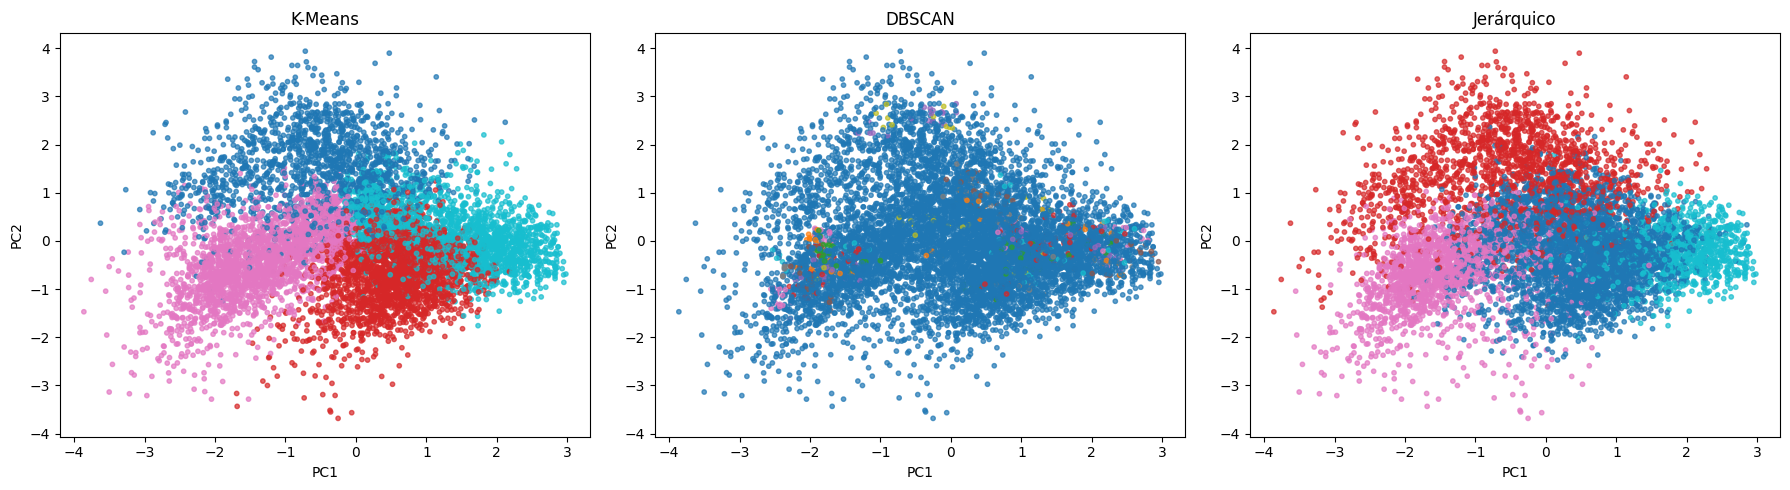

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# K-Means
scatter0 = axes[0].scatter(X_pca_2[:,0], X_pca_2[:,1], c=labels_kmeans, cmap='tab10', s=10, alpha=0.7)
axes[0].set_title('K-Means')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

# DBSCAN
scatter1 = axes[1].scatter(X_pca_2[:,0], X_pca_2[:,1], c=labels_dbscan, cmap='tab10', s=10, alpha=0.7)
axes[1].set_title('DBSCAN')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

# Jerárquico
scatter2 = axes[2].scatter(X_pca_2[:,0], X_pca_2[:,1], c=labels_agg, cmap='tab10', s=10, alpha=0.7)
axes[2].set_title('Jerárquico')
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')

plt.tight_layout()
plt.show()

## 7. Guardado de figuras para el informe

Guardamos algunas figuras clave (gráficos de PCA con clústeres) como archivos `.png` para poder insertarlas en el informe final en PDF o Google Docs.


In [7]:
import os
os.makedirs('figuras', exist_ok=True)

# K-Means
plt.figure(figsize=(6,6))
plt.scatter(X_pca_2[:,0], X_pca_2[:,1], c=labels_kmeans, cmap='tab10', s=10, alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-Means sobre PCA')
plt.savefig('figuras/kmeans_pca.png', dpi=300, bbox_inches='tight')
plt.close()

# DBSCAN
plt.figure(figsize=(6,6))
plt.scatter(X_pca_2[:,0], X_pca_2[:,1], c=labels_dbscan, cmap='tab10', s=10, alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('DBSCAN sobre PCA')
plt.savefig('figuras/dbscan_pca.png', dpi=300, bbox_inches='tight')
plt.close()

# Jerárquico
plt.figure(figsize=(6,6))
plt.scatter(X_pca_2[:,0], X_pca_2[:,1], c=labels_agg, cmap='tab10', s=10, alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Jerárquico sobre PCA')
plt.savefig('figuras/jerarquico_pca.png', dpi=300, bbox_inches='tight')
plt.close()

os.listdir('figuras')

['dbscan_pca.png', 'jerarquico_pca.png', 'kmeans_pca.png']

## 8. Guía para el informe final (texto sugerido)

A continuación se propone una estructura de texto para el informe final, que puedes redactar en un documento aparte (PDF o Google Docs):

1. **Contexto y objetivo**
   - Describir el problema de negocio (segmentación de clientes para personalizar campañas).
   - Explicar por qué se usa aprendizaje no supervisado y clusterización.

2. **Datos y preprocesamiento**
   - Describir brevemente las variables disponibles en `Train.csv` y `Test.csv`.
   - Explicar cómo se trataron los valores nulos, cómo se escalaron las variables numéricas y cómo se codificaron las categóricas.

3. **Metodología de segmentación**
   - Explicar el uso de PCA y t-SNE para reducir dimensionalidad y visualizar.
   - Describir los algoritmos de clusterización utilizados (K-Means, DBSCAN, jerárquico).
   - Justificar la elección de parámetros clave (por ejemplo, valor de k en K-Means, eps y min_samples en DBSCAN).

4. **Resultados de los clústeres**
   - Presentar la tabla de métricas (silueta, número de clústeres, ruido).
   - Incluir gráficos de PCA con los clústeres (imágenes guardadas en la carpeta `figuras`).
   - Describir, en lenguaje de negocio, las características principales de cada segmento (por ejemplo, clientes de alto ingreso, clientes jóvenes con bajo gasto, etc.).

5. **Recomendaciones comerciales**
   - Proponer acciones de marketing para cada segmento: campañas específicas, productos recomendados, estrategias de retención.

6. **Conclusiones y trabajo futuro**
   - Resumir los hallazgos clave.
   - Mencionar posibles mejoras: probar otros algoritmos, ajustar parámetros, incorporar nuevas variables, etc.
